# TF-IDF and Bag-of-Words Phishing Classifier — Test + OOD Evaluation


- **Bag-of-Words + Logistic Regression**
- **TF-IDF + Logistic Regression**

1. loads and splits the main `Phishing_Email.csv` dataset,
2. trains both models on the training split,
3. evaluates both on the held-out **test** split,
4. runs **out-of-distribution (OOD)** evaluation on external datasets

In [1]:
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Seed:", SEED)
warnings.simplefilter("ignore")

Seed: 42


In [2]:
# Load and Split Data
data_df = pd.read_csv('Phishing_Email.csv')
train_size = .8
validation_size = .1
test_size = .1

# Uses global Seed for random_state
train_df, temp_df = train_test_split(data_df, train_size = train_size, random_state= SEED)
validation_df, test_df = train_test_split(temp_df, test_size=.5, random_state= SEED)

# Configure Pandas Display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 70)
pd.set_option('display.expand_frame_rep', False)


print("Training Data shape:", train_df.shape)
print("Validation Data shape:", validation_df.shape)
print("Testing Data shape:", test_df.shape)
print()
print("Below is a small sample of what the data we will be using looks like:")

sample_phishing = train_df[train_df['Email Type'] == 'Phishing Email'].sample(n=3, random_state=SEED)
sample_safe = train_df[train_df['Email Type'] == 'Safe Email'].sample(n=3, random_state=SEED)

print(pd.concat([sample_phishing, sample_safe]))

Training Data shape: (14920, 3)
Validation Data shape: (1865, 3)
Testing Data shape: (1865, 3)

Below is a small sample of what the data we will be using looks like:
      Unnamed: 0                                                             Email Text      Email Type
6199        6199  sorry , one more thing cheating adult personals get laid now . rea...  Phishing Email
5658        5658  payment representative dear sir / madam , i am mr . liu peijin , m...  Phishing Email
5466        5466  When Economy goes down, WE go UP !$3000 COMMISSION per Sale for YO...  Phishing Email
7321        7322  fifth annual graduate romanic association at the u . of penn . * *...      Safe Email
3140        3140  december conference preliminary announcement first international w...      Safe Email
3510        3510  re : term project : brian , no problem . vince " brian corbett nel...      Safe Email


## Bag-of-Words + Logistic Regression

In [3]:
train_email_text = train_df["Email Text"].fillna("")
test_email_text = test_df["Email Text"].fillna("")

print("Initializing CountVectorizer (unigrams + bigrams, stopwords removed)...\n")
bow_vectorizer = CountVectorizer(stop_words = 'english', ngram_range=(1,2) )

print("Vectorizing training email text (learning vocabulary)...")
X_train = bow_vectorizer.fit_transform(train_email_text)

print("Vectorizing TEST email text using learned vocabulary...\n")
X_val = bow_vectorizer.transform(test_email_text)

print(f"Vocabulary size (number of features): {X_train.shape[1]}")

print("Encoding email labels as binary values (1 = phishing, 0 = safe)\n")
Y_train = (train_df["Email Type"] == "Phishing Email").astype(int)
Y_val = (test_df["Email Type"] == "Phishing Email").astype(int)
print("Done!")

Initializing CountVectorizer (unigrams + bigrams, stopwords removed)...

Vectorizing training email text (learning vocabulary)...
Vectorizing TEST email text using learned vocabulary...

Vocabulary size (number of features): 1445686
Encoding email labels as binary values (1 = phishing, 0 = safe)

Done!


In [4]:
print("Training Logistic Regression classifier with Bag-of-Words Features...\n")
bow_lr_classifier = LogisticRegression(penalty="l2",max_iter=3000,random_state = SEED)

bow_lr_classifier.fit(X_train, Y_train)

y_pred = bow_lr_classifier.predict(X_val)

y_proba = bow_lr_classifier.predict_proba(X_val)[:, 1]

print("Evaluating model performance on TEST data...")
print("Test Accuracy:", accuracy_score(Y_val, y_pred))
print("Test AUROC:", roc_auc_score(Y_val, y_proba))

print("\nDetailed Classification Report: Bag-of-Words Features")
print(classification_report(Y_val, y_pred, target_names=["Safe Email", "Phishing Email"], digits=4))

Training Logistic Regression classifier with Bag-of-Words Features...

Evaluating model performance on TEST data...
Test Accuracy: 0.974798927613941
Test AUROC: 0.9964627518702065

Detailed Classification Report: Bag-of-Words Features
                precision    recall  f1-score   support

    Safe Email     0.9884    0.9701    0.9792      1139
Phishing Email     0.9545    0.9821    0.9681       726

      accuracy                         0.9748      1865
     macro avg     0.9714    0.9761    0.9736      1865
  weighted avg     0.9752    0.9748    0.9749      1865



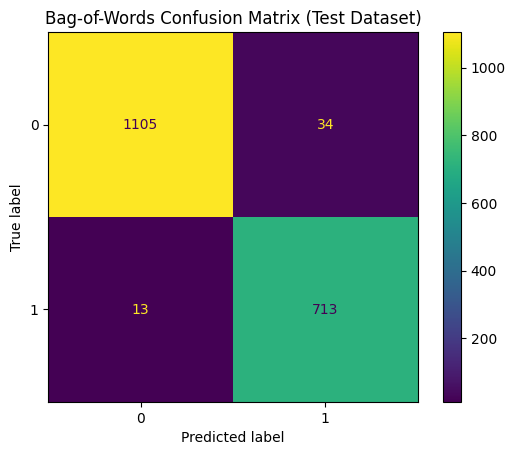

In [5]:
y_pred = bow_lr_classifier.predict(X_val)
c_matrix = confusion_matrix(Y_val, y_pred)
ConfusionMatrixDisplay(confusion_matrix=c_matrix).plot()
plt.title("Bag-of-Words Confusion Matrix (Test Dataset)")
plt.show()

## TF-IDF + Logistic Regression

In [6]:
# These remain the same for both feature types # 
train_email_text = train_df["Email Text"].fillna("")
test_email_text = test_df["Email Text"].fillna("")

print("Initializing TF-IDF Vectorizer (unigrams + bigrams, stopwords removed)...\n")
tf_idf_vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    min_df=2,          # helps remove noise
    max_df=0.95,       # ignore extremely common terms
    sublinear_tf=True  # 1 + log(tf)
)

print("Vectorizing training email text (learning vocabulary)...")
X_train = tf_idf_vectorizer.fit_transform(train_email_text)

print("Vectorizing TEST email text using learned vocabulary...\n")
X_val = tf_idf_vectorizer.transform(test_email_text)

print(f"Vocabulary size (number of features): {X_train.shape[1]}")

# These remain the same for both feature types # 
print("Encoding email labels as binary values (1 = phishing, 0 = safe)\n")
Y_train = (train_df["Email Type"] == "Phishing Email").astype(int)
Y_val = (test_df["Email Type"] == "Phishing Email").astype(int)
print("Done!")

Initializing TF-IDF Vectorizer (unigrams + bigrams, stopwords removed)...

Vectorizing training email text (learning vocabulary)...
Vectorizing TEST email text using learned vocabulary...

Vocabulary size (number of features): 636676
Encoding email labels as binary values (1 = phishing, 0 = safe)

Done!


In [7]:
print("Training Logistic Regression classifier with TF-IDF Features...\n")
tf_idf_lr_classifier = LogisticRegression(penalty="l2",max_iter=3000,random_state = SEED )

tf_idf_lr_classifier.fit(X_train, Y_train)

y_pred = tf_idf_lr_classifier.predict(X_val)

y_proba = tf_idf_lr_classifier.predict_proba(X_val)[:, 1]

print("Evaluating model performance on TEST data...")
print("Test Accuracy:", accuracy_score(Y_val, y_pred))
print("Test AUROC:", roc_auc_score(Y_val, y_proba))

print("\nDetailed Classification Report: TF-IDF Features")
print(classification_report(Y_val, y_pred, target_names=["Safe Email", "Phishing Email"],digits=4))

Training Logistic Regression classifier with TF-IDF Features...

Evaluating model performance on TEST data...
Test Accuracy: 0.9731903485254692
Test AUROC: 0.9974749490273476

Detailed Classification Report: TF-IDF Features
                precision    recall  f1-score   support

    Safe Email     0.9806    0.9754    0.9780      1139
Phishing Email     0.9617    0.9697    0.9657       726

      accuracy                         0.9732      1865
     macro avg     0.9712    0.9726    0.9718      1865
  weighted avg     0.9733    0.9732    0.9732      1865



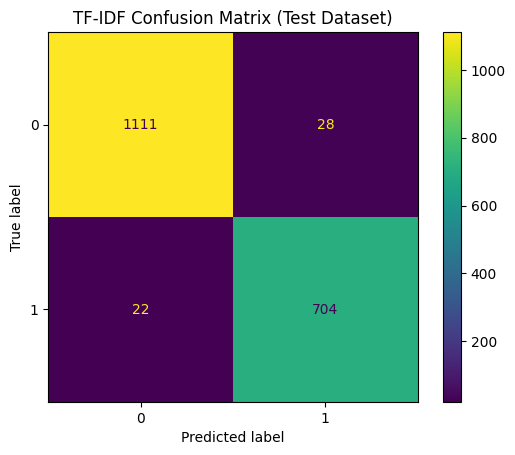

In [8]:
y_pred = tf_idf_lr_classifier.predict(X_val)
c_matrix = confusion_matrix(Y_val, y_pred)
ConfusionMatrixDisplay(confusion_matrix=c_matrix).plot()
plt.title("TF-IDF Confusion Matrix (Test Dataset)")
plt.show()

## Out-of-Distribution Evaluation

This follows the same pattern as the BERT evaluation notebook and uses the same dataset names:
- `CEAS_08.csv`
- `Nigerian_5.csv`
- `Nazario_5.csv`
- `Nazario.csv`
- `SpamAssasin.csv`
- `Nigerian_Fraud.csv`

In [9]:
OOD_DATASETS = [
    ("CEAS_08.csv", "CEAS_08"),
    ("Nigerian_5.csv", "Nigerian_5"),
    ("Nazario_5.csv", "Nazario_5"),
    ("Nazario.csv", "Nazario"),
    ("SpamAssasin.csv", "SpamAssasin"),
    ("Nigerian_Fraud.csv", "Nigerian Fraud"),
]

missing = [path for path, _ in OOD_DATASETS if not Path(path).exists()]
if missing:
    print("Missing OOD files:")
    for item in missing:
        print(" -", item)
    print("\nPlace those CSV files in the same folder as this notebook before running the OOD section.")
else:
    print("All OOD files found.")

All OOD files found.


### OOD helper function

In [10]:
def evaluate_ood_dataset(path, title, fitted_vectorizer, trained_model, min_n=50):
    df = pd.read_csv(path)

    has_date = "date" in df.columns
    if has_date:
        df["year"] = pd.to_datetime(df["date"], errors="coerce", utc=True).dt.year.fillna(-1).astype(int)

    df["body"] = df["body"].fillna("").astype(str)
    df["label"] = df["label"].astype(int)

    X_ood = fitted_vectorizer.transform(df["body"])

    df["pred"] = trained_model.predict(X_ood)
    y_proba = trained_model.predict_proba(X_ood)[:, 1]

    print(f"\n{'='*50}")
    print(f"{title}")
    print(f"{'='*50}")
    print(f"Shape: {df.shape}")
    print(classification_report(
        df["label"],
        df["pred"],
        target_names=["Safe Email", "Phishing Email"],
        digits=4,
        zero_division=0
    ))

    if df["label"].nunique() > 1:
        print("AUROC:", roc_auc_score(df["label"], y_proba))
    else:
        print("AUROC: skipped (only one class present in this dataset)")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    if has_date:
        yr_df = pd.DataFrame([
            {
                "year": y,
                "n": (m := df["year"] == y).sum(),
                "accuracy": accuracy_score(df.loc[m, "label"], df.loc[m, "pred"])
            }
            for y in sorted(df["year"].unique()) if y != -1
        ])

        yr_df = yr_df[yr_df["n"] >= min_n].sort_values("year")

        if not yr_df.empty:
            axes[0].plot(
                yr_df["year"],
                yr_df["accuracy"],
                marker="o",
                linewidth=2,
                markersize=6
            )

            for _, row in yr_df.iterrows():
                axes[0].annotate(
                    f'{row["accuracy"]:.3f}',
                    (row["year"], row["accuracy"]),
                    textcoords="offset points",
                    xytext=(0, 8),
                    ha="center",
                    fontsize=9
                )

            axes[0].set_ylim(0, 1.05)
            axes[0].set_title(f"Accuracy by Year (n ≥ {min_n})", fontsize=13)
            axes[0].set_xlabel("Year", fontsize=11)
            axes[0].set_ylabel("Accuracy", fontsize=11)
            axes[0].set_xticks(yr_df["year"])
            axes[0].tick_params(axis="x", rotation=45, labelsize=10)
            axes[0].tick_params(axis="y", labelsize=10)
            axes[0].grid(True, linestyle="--", alpha=0.4)
        else:
            axes[0].text(0.5, 0.5, "No year groups meet threshold", ha="center", va="center", fontsize=12)
            axes[0].set_title("Accuracy by Year", fontsize=13)
    else:
        axes[0].text(0.5, 0.5, "No date column available", ha="center", va="center", fontsize=12)
        axes[0].set_title("Accuracy by Year", fontsize=13)

    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(df["label"], df["pred"]),
        display_labels=["Safe", "Phishing"]
    ).plot(ax=axes[1], colorbar=False)

    axes[1].set_title(f"Confusion Matrix — {title}", fontsize=13)
    axes[1].tick_params(axis="x", rotation=0, labelsize=10)
    axes[1].tick_params(axis="y", labelsize=10)

    plt.tight_layout(pad=2.0)
    plt.show()

    return df

### Bag-of-Words model on OOD datasets

Running Bag-of-Words model on OOD datasets...


CEAS_08 (Bag-of-Words)
Shape: (39154, 9)
                precision    recall  f1-score   support

    Safe Email     0.8195    0.8884    0.8525     17312
Phishing Email     0.9052    0.8449    0.8740     21842

      accuracy                         0.8641     39154
     macro avg     0.8624    0.8666    0.8633     39154
  weighted avg     0.8673    0.8641    0.8645     39154

AUROC: 0.8183177373913408


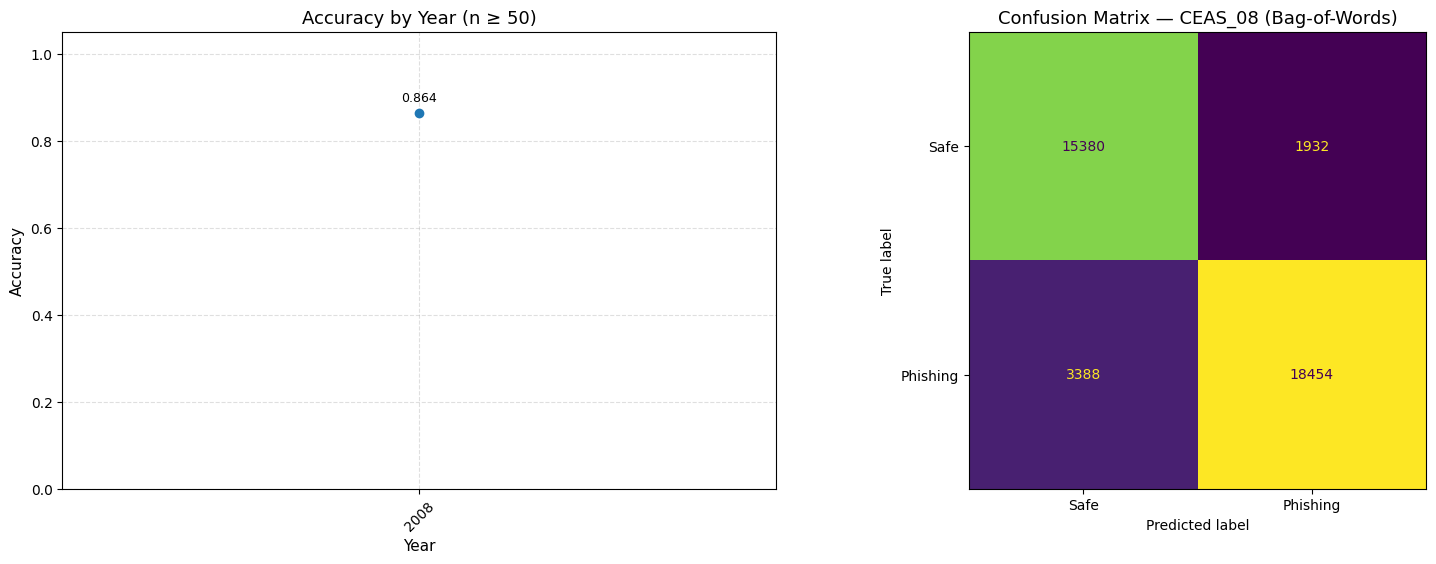


Nigerian_5 (Bag-of-Words)
Shape: (6331, 9)
                precision    recall  f1-score   support

    Safe Email     0.9789    0.9120    0.9442      2999
Phishing Email     0.9254    0.9823    0.9530      3332

      accuracy                         0.9490      6331
     macro avg     0.9521    0.9471    0.9486      6331
  weighted avg     0.9507    0.9490    0.9488      6331

AUROC: 0.9833059599298205


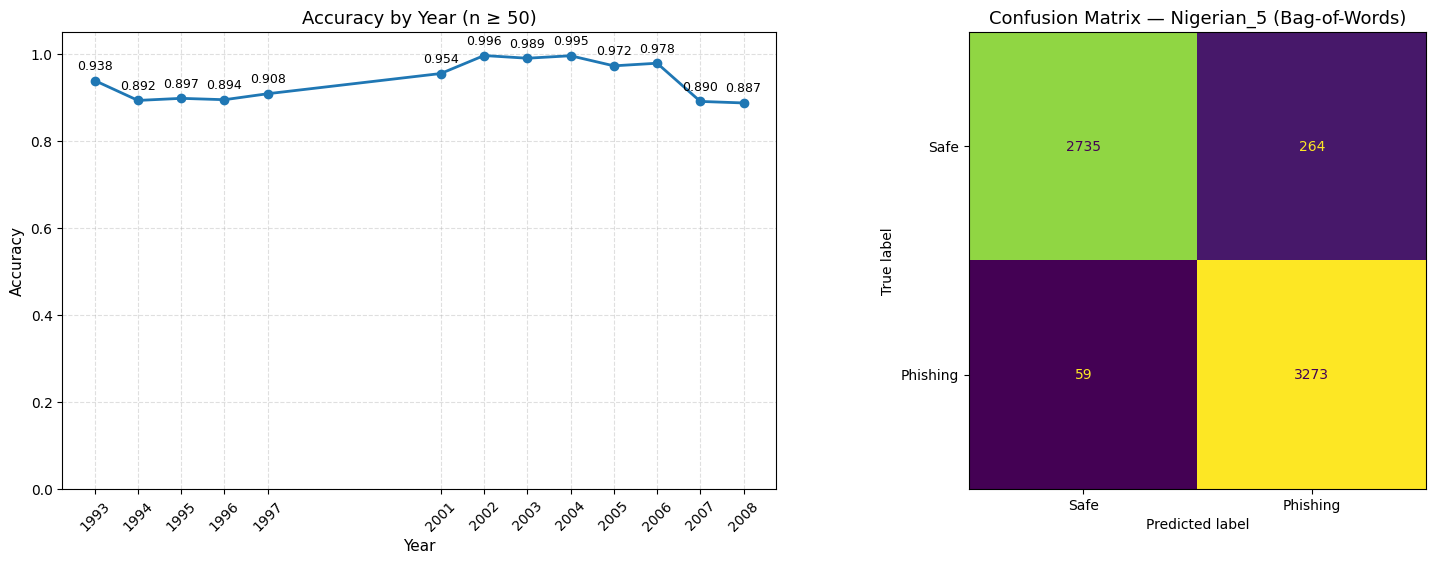


Nazario_5 (Bag-of-Words)
Shape: (3065, 9)
                precision    recall  f1-score   support

    Safe Email     0.7599    0.9053    0.8263      1500
Phishing Email     0.8889    0.7259    0.7992      1565

      accuracy                         0.8137      3065
     macro avg     0.8244    0.8156    0.8127      3065
  weighted avg     0.8258    0.8137    0.8124      3065

AUROC: 0.9086543130990415


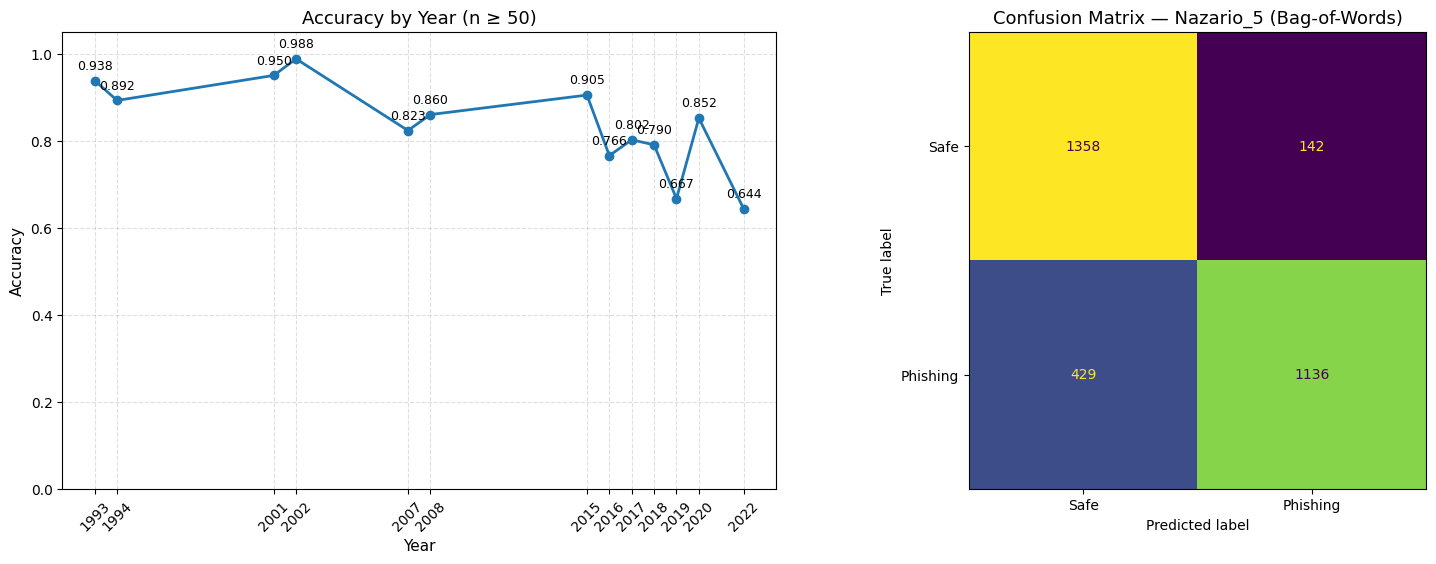


Nazario (Bag-of-Words)
Shape: (1565, 9)
                precision    recall  f1-score   support

    Safe Email     0.0000    0.0000    0.0000         0
Phishing Email     1.0000    0.7259    0.8412      1565

      accuracy                         0.7259      1565
     macro avg     0.5000    0.3629    0.4206      1565
  weighted avg     1.0000    0.7259    0.8412      1565

AUROC: skipped (only one class present in this dataset)


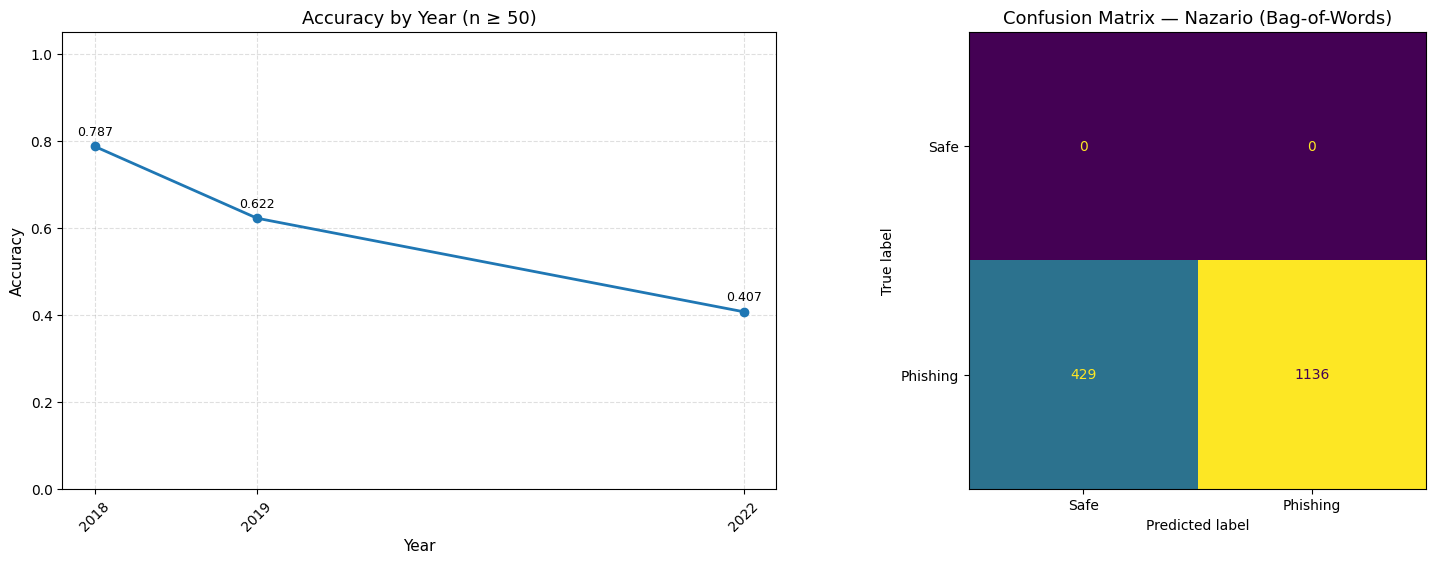


SpamAssasin (Bag-of-Words)
Shape: (5809, 9)
                precision    recall  f1-score   support

    Safe Email     0.9946    0.9861    0.9903      4091
Phishing Email     0.9675    0.9872    0.9772      1718

      accuracy                         0.9864      5809
     macro avg     0.9810    0.9866    0.9838      5809
  weighted avg     0.9866    0.9864    0.9864      5809

AUROC: 0.9916007881237355


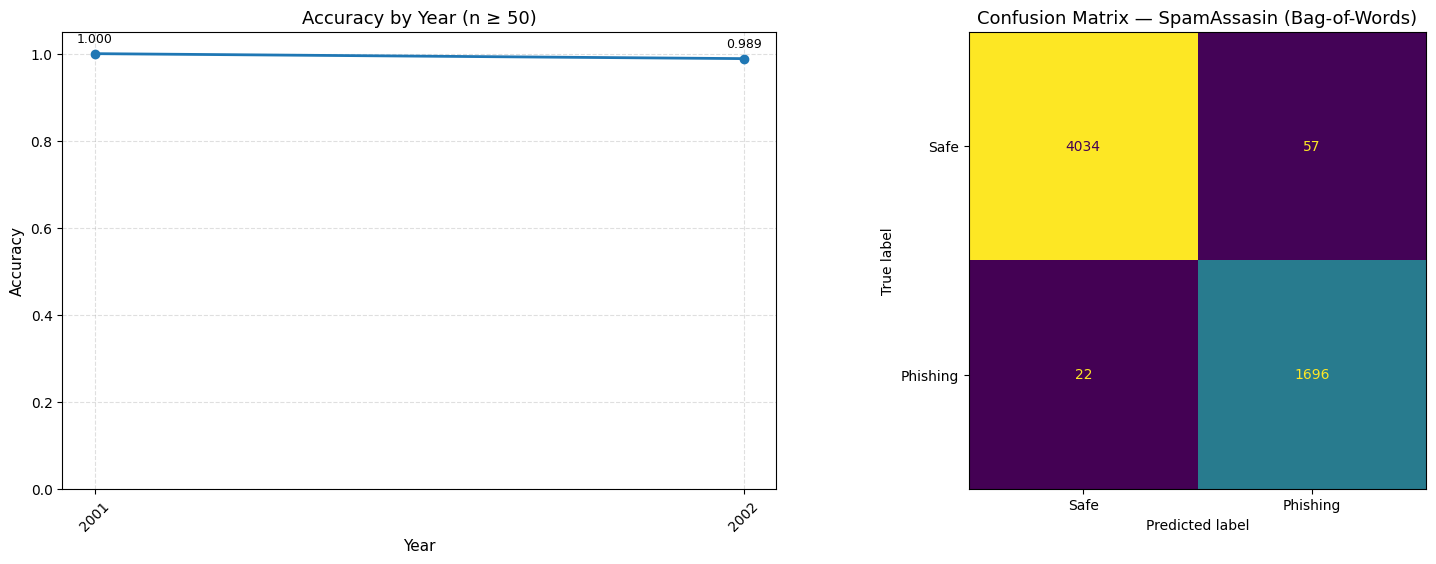


Nigerian Fraud (Bag-of-Words)
Shape: (3332, 9)
                precision    recall  f1-score   support

    Safe Email     0.0000    0.0000    0.0000         0
Phishing Email     1.0000    0.9823    0.9911      3332

      accuracy                         0.9823      3332
     macro avg     0.5000    0.4911    0.4955      3332
  weighted avg     1.0000    0.9823    0.9911      3332

AUROC: skipped (only one class present in this dataset)


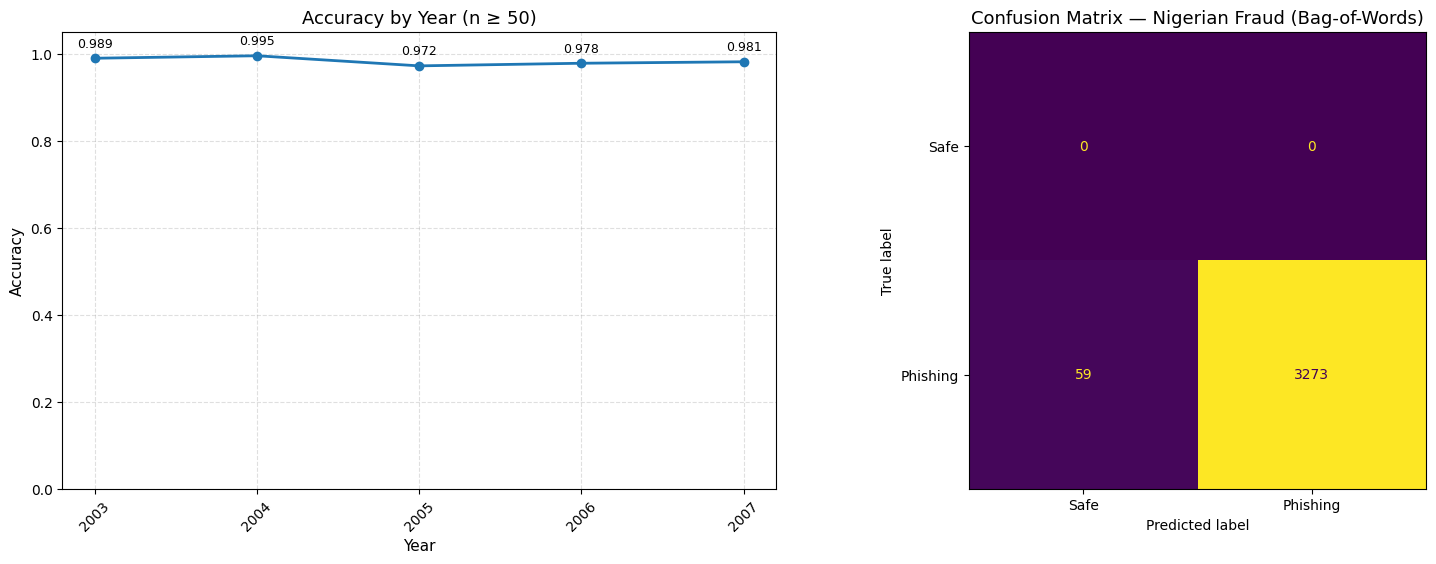

In [11]:
print("Running Bag-of-Words model on OOD datasets...\n")

bow_ood_results = {}

for path, title in OOD_DATASETS:
    bow_ood_results[title] = evaluate_ood_dataset(
        path=path,
        title=f"{title} (Bag-of-Words)",
        fitted_vectorizer=bow_vectorizer,
        trained_model=bow_lr_classifier
    )

### TF-IDF model on OOD datasets

Running TF-IDF model on OOD datasets...


CEAS_08 (TF-IDF)
Shape: (39154, 9)
                precision    recall  f1-score   support

    Safe Email     0.7977    0.9224    0.8556     17312
Phishing Email     0.9298    0.8146    0.8684     21842

      accuracy                         0.8623     39154
     macro avg     0.8638    0.8685    0.8620     39154
  weighted avg     0.8714    0.8623    0.8627     39154

AUROC: 0.9446290647112577


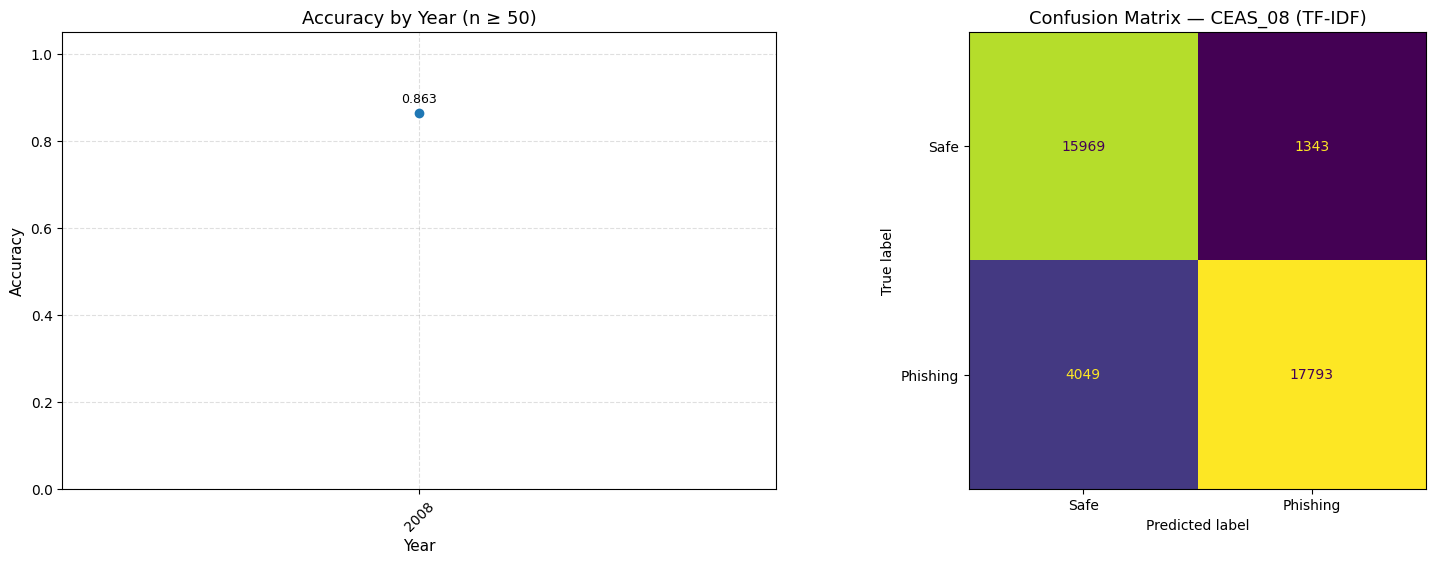


Nigerian_5 (TF-IDF)
Shape: (6331, 9)
                precision    recall  f1-score   support

    Safe Email     0.9900    0.9527    0.9709      2999
Phishing Email     0.9588    0.9913    0.9748      3332

      accuracy                         0.9730      6331
     macro avg     0.9744    0.9720    0.9729      6331
  weighted avg     0.9735    0.9730    0.9730      6331

AUROC: 0.9963342122444174


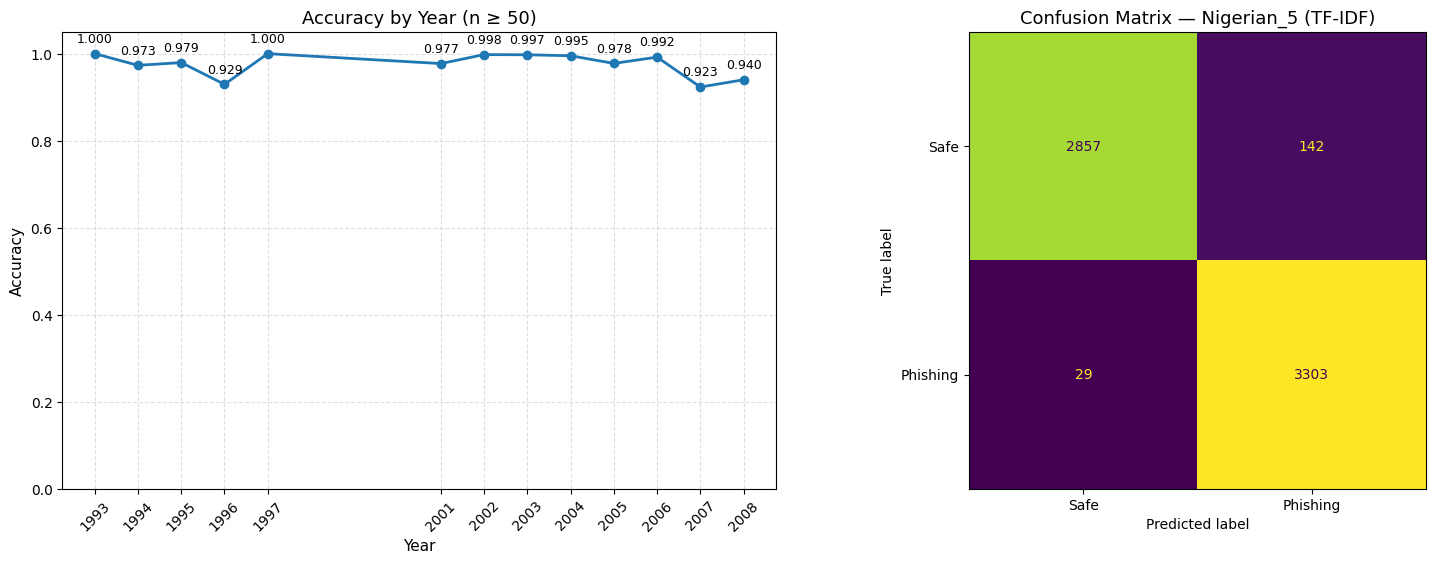


Nazario_5 (TF-IDF)
Shape: (3065, 9)
                precision    recall  f1-score   support

    Safe Email     0.7566    0.9427    0.8394      1500
Phishing Email     0.9281    0.7093    0.8041      1565

      accuracy                         0.8235      3065
     macro avg     0.8423    0.8260    0.8217      3065
  weighted avg     0.8441    0.8235    0.8214      3065

AUROC: 0.9423761448349307


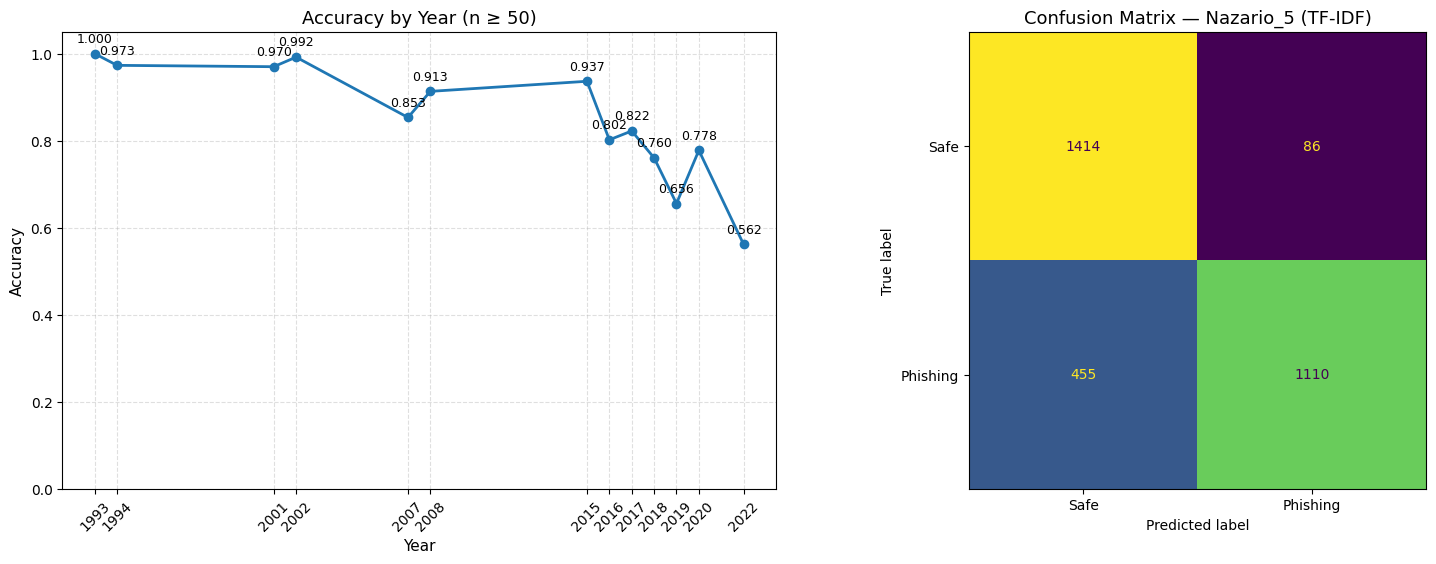


Nazario (TF-IDF)
Shape: (1565, 9)
                precision    recall  f1-score   support

    Safe Email     0.0000    0.0000    0.0000         0
Phishing Email     1.0000    0.7093    0.8299      1565

      accuracy                         0.7093      1565
     macro avg     0.5000    0.3546    0.4150      1565
  weighted avg     1.0000    0.7093    0.8299      1565

AUROC: skipped (only one class present in this dataset)


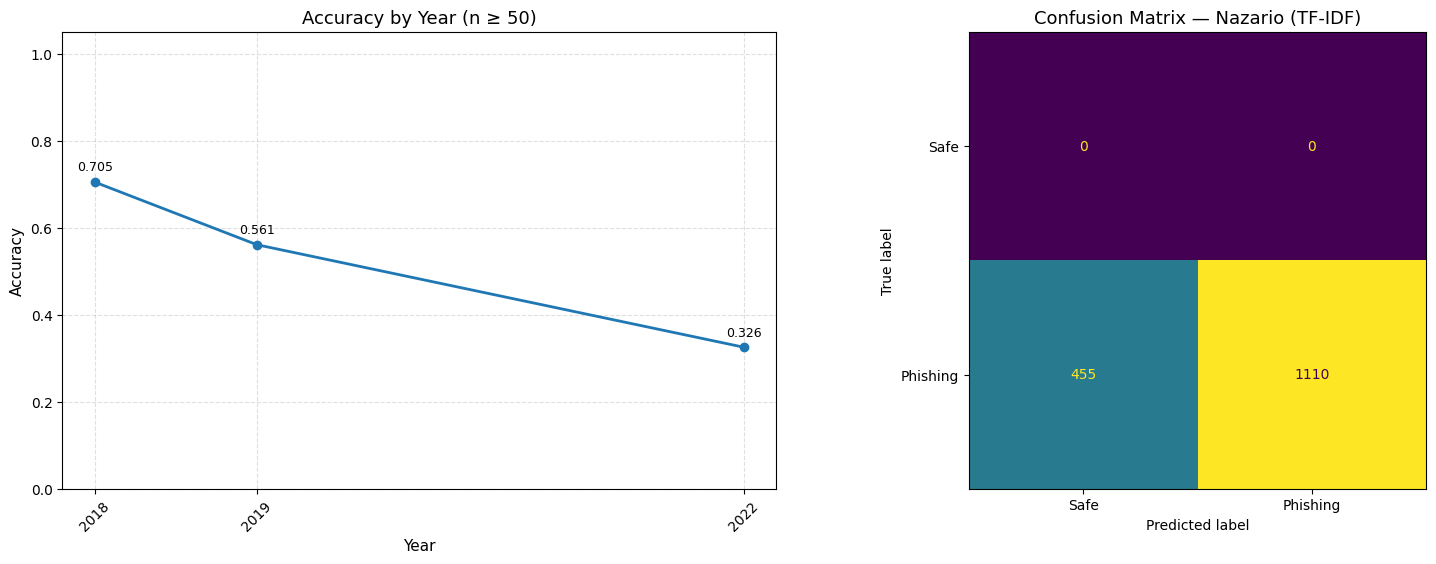


SpamAssasin (TF-IDF)
Shape: (5809, 9)
                precision    recall  f1-score   support

    Safe Email     0.9878    0.9875    0.9877      4091
Phishing Email     0.9703    0.9709    0.9706      1718

      accuracy                         0.9826      5809
     macro avg     0.9791    0.9792    0.9791      5809
  weighted avg     0.9826    0.9826    0.9826      5809

AUROC: 0.9956636974488136


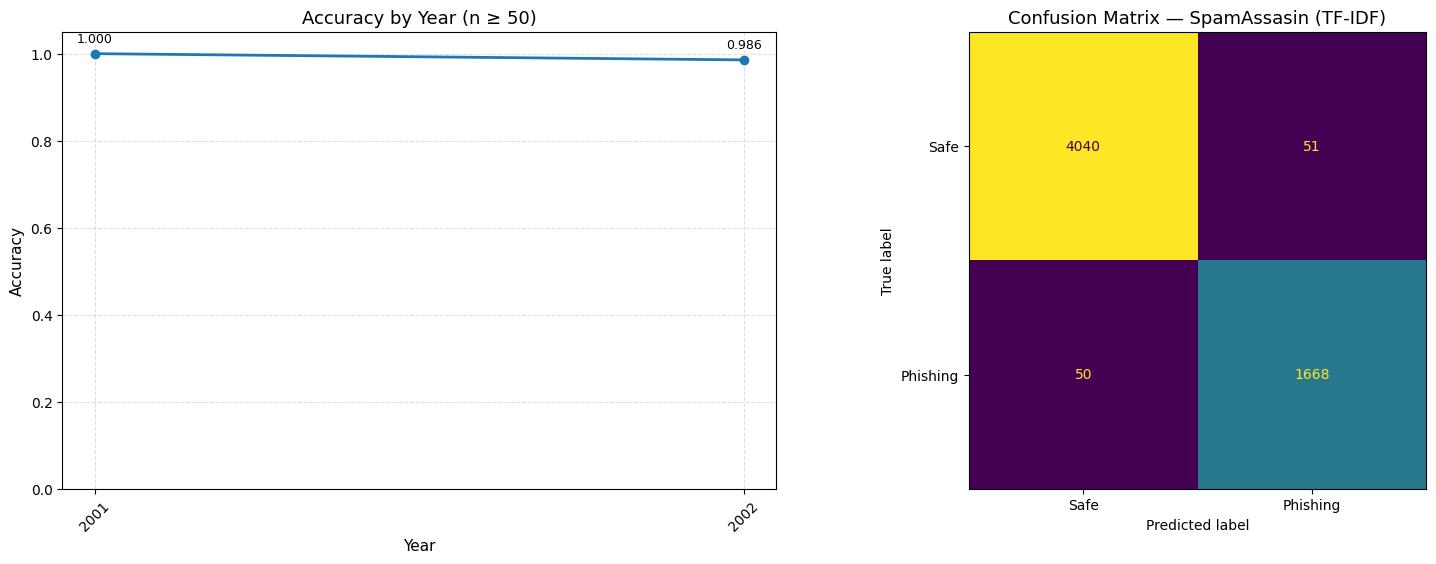


Nigerian Fraud (TF-IDF)
Shape: (3332, 9)
                precision    recall  f1-score   support

    Safe Email     0.0000    0.0000    0.0000         0
Phishing Email     1.0000    0.9913    0.9956      3332

      accuracy                         0.9913      3332
     macro avg     0.5000    0.4956    0.4978      3332
  weighted avg     1.0000    0.9913    0.9956      3332

AUROC: skipped (only one class present in this dataset)


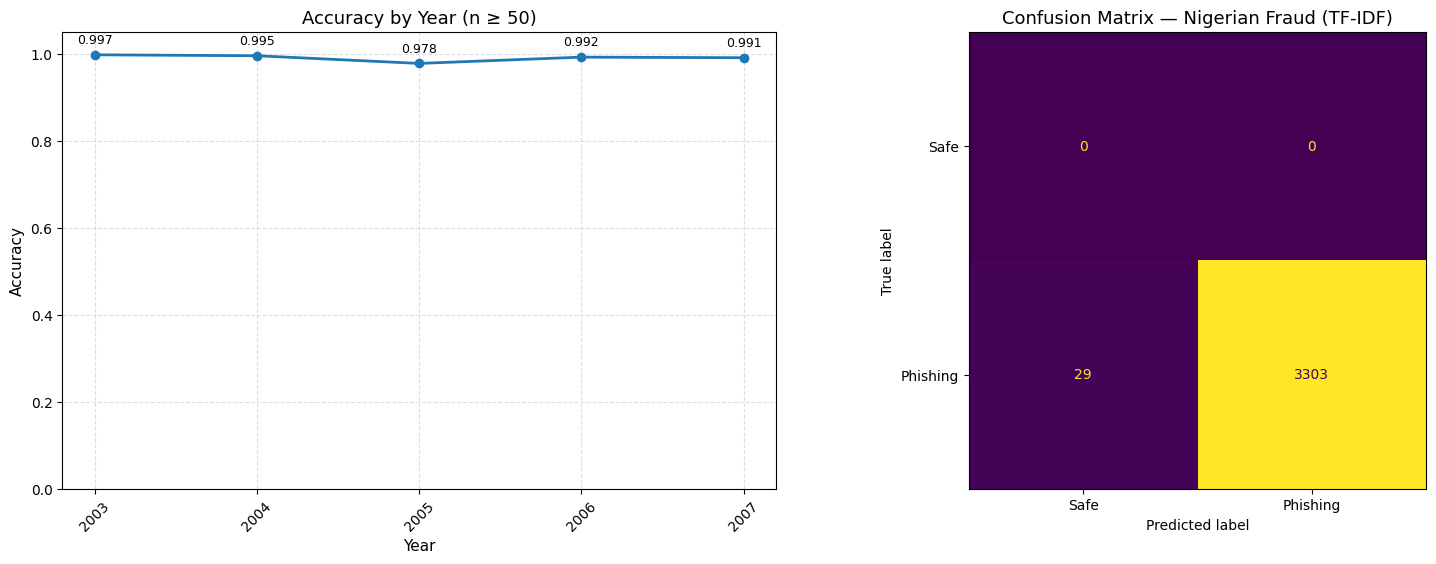

In [12]:
print("Running TF-IDF model on OOD datasets...\n")

tfidf_ood_results = {}

for path, title in OOD_DATASETS:
    tfidf_ood_results[title] = evaluate_ood_dataset(
        path=path,
        title=f"{title} (TF-IDF)",
        fitted_vectorizer=tf_idf_vectorizer,
        trained_model=tf_idf_lr_classifier
    )

### Summary Table

In [13]:
summary_rows = []

for title, df in bow_ood_results.items():
    summary_rows.append({
        "Model": "Bag-of-Words",
        "Dataset": title,
        "Accuracy": accuracy_score(df["label"], df["pred"])
    })

for title, df in tfidf_ood_results.items():
    summary_rows.append({
        "Model": "TF-IDF",
        "Dataset": title,
        "Accuracy": accuracy_score(df["label"], df["pred"])
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.sort_values(["Model", "Dataset"]).reset_index(drop=True))

,Model,Dataset,Accuracy
0,Bag-of-Words,CEAS_08,0.864126
1,Bag-of-Words,Nazario,0.725879
2,Bag-of-Words,Nazario_5,0.813703
3,Bag-of-Words,Nigerian Fraud,0.982293
4,Bag-of-Words,Nigerian_5,0.948981
5,Bag-of-Words,SpamAssasin,0.986400
6,TF-IDF,CEAS_08,0.862287
7,TF-IDF,Nazario,0.709265
8,TF-IDF,Nazario_5,0.823491
9,TF-IDF,Nigerian Fraud,0.991297
